# Tipos de Clasificacion

Los modelos se pueden clasificar en tres grupos en funcion de las caracteristicas de las variables objetivo.

1. **Binaria:**La variable objetivo tiene dos categorias posibles. El ejemplo mas comun son si/no, bueno/malo, verdadero/falso, spam/no spam, pasar/fallar.

2. **Multinomial:** La variable objetivo tiene tres o mas categorias que no estan en ningun orden particular (nominales). Ejemplo: Manzana, Mango, Naranja.

3. **Ordinales:** La variable objetivo tiene tres o mas categorias ordinales. Osea hay un orden intriseco involucrado. Ejemplo, el rendimiento de un trabajador malo, promedio, bueno, excelente.

# Regresion Logistica

Es un algoritmo de clasificacion de tipo aprendizaje supervisado que se utiliza para predecir observaciones a un conjunto de datos discretos.

## Funcionamiento del Algoritmo al Implementar una Ecuacion Lineal

El algoritmo de regresión logística funciona implementando una ecuación lineal con variables independientes o explicativas para predecir un valor de respuesta. Por ejemplo, consideramos el ejemplo del número de horas estudiadas y la probabilidad de aprobar el examen. Aquí, el número de horas estudiadas es la variable explicativa y se denota por x1. La probabilidad de aprobar el examen es la variable de respuesta o objetivo y se denota por z.

Si **p** es la probabilidad de que variable salida sea **l**, la funcion logit se define **log(p / (1-p))**. Un conjunto de datos con x1,x2,x3.., xn, la funcion logit se podria entender de la siguiente forma **log ( p (1-p) = B0 + B1*X1 + B2*X2 + ...... Bn*Xn **

Si tenemos una variable explicativa (x1) y una variable de respuesta (z), entonces la ecuación lineal se daría matemáticamente con la siguiente ecuación:

**z = b0 + b1x1**



Aquí, los coeficientes β0 y β1 son los parámetros del modelo.

Si hay múltiples variables explicativas, entonces la ecuación anterior se puede extender a

**z = b0 + b1x1+ b2x2+........+ bnxn**



Aquí, los coeficientes β0, β1, β2 y βn son los parámetros del modelo.

Por lo tanto, el valor de respuesta predicho está dado por las ecuaciones anteriores y se denota por z.

## Funcion Sigmoide

Este valor de respuesta predicho, denotado por z, se convierte en un valor de probabilidad que se encuentra entre 0 y 1. Utilizamos la función sigmoide para asignar los valores predichos a los valores de probabilidad. Esta función sigmoide luego mapea cualquier valor real en un valor de probabilidad entre 0 y 1.
En el aprendizaje automático, la función sigmoide se utiliza para asignar predicciones a probabilidades. La función sigmoide tiene una curva en forma de S. También se llama curva sigmoidea.

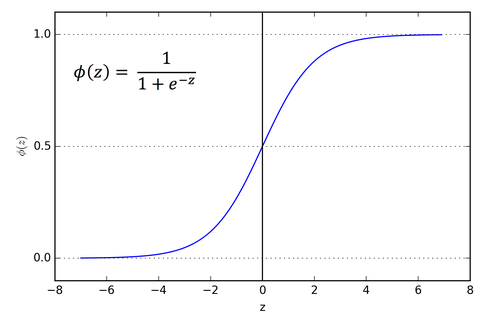

p = 1 / (1 + e-z(B0 +B1*X1 +B2*X2 + BN*XN)

## Limite de Decision

La función sigmoide devuelve un valor de probabilidad entre 0 y 1. Este valor de probabilidad se asigna a una clase discreta que es "0" o "1". Para asignar este valor de probabilidad a una clase discreta (aprobado/reprobado, sí/no, verdadero/falso), seleccionamos un valor umbral. Este valor de umbral se denomina límite de decisión. Por encima de este valor umbral, asignaremos los valores de probabilidad en la clase 1 y por debajo de los cuales asignaremos los valores en la clase 0.

Matemáticamente, se puede expresar de la siguiente manera:

p ≥ 0,5 = clase > = 1

p < 0,5 = clase > = 0

Generalmente, el límite de decisión se establece en 0,5. Por lo tanto, si el valor de probabilidad es 0.8 (> 0.5), asignaremos esta observación a la clase 1. Del mismo modo, si el valor de probabilidad es 0.2 (< 0.5), asignaremos esta observación a la clase 0. Esto se representa en el gráfico a continuación.

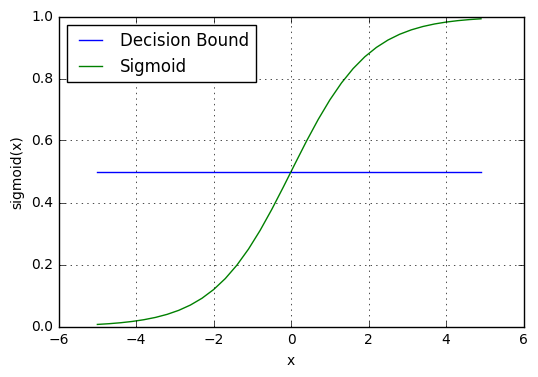

## Supuesto de Regresion Logistica

1. El modelo de regresion logistica requiere que la variable dependiente (la que vamos a predecir) sea de naturaleza binaria u ordinal, tambien podria ser multinomial (pero no es el mejor modelo para ese tipo ejemplos)

2. Requiere que las observaciones sea independientes entre si. Por lo tanto, las observaciones no deben de provenir de mediciones repetidas.

3. El algoritmo de regresion logistica requiere poca o ninguna multicolinealidad entre las variables independientes. Significa que las variables independientes no deben estar demasiado correlacionadas entre si.

4. El modelo de regresion logistica asume la linealidad de las variables independientes (las x) y las probabilidades logaritmos.

5. El exito de estos modelo de regresion logistica depende del tamanio de la muestra. Por lo general requiere un gran tamanio de muestra para lograr la alta precision.

## Instalar librerías

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.5 MB/s eta 0:00:00


## Importar las Librerias

In [ ]:
import numpy as np #algebra lineal
import pandas as pd #procesamiento datos
import matplotlib.pyplot as plt #Visualizacion de Datos
import seaborn as sns # Visualizaciones estadisticas
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler
from category_encoders import BinaryEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, log_loss, cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## Cargar los datos

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/weatherAUS.csv')

## Analisis Exploratorio

In [ ]:
# Ver dimensiones del dataset

df.shape

(145460, 23)

In [ ]:
#Visualizacion previa del dataset

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
nombre_columnas = df.columns

nombre_columnas

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [ ]:
# El Resumen del Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

## Conocer el Tipo de Variables

Vamos a segregar el dataset en variables categoricas y variables numericas.

Las variables categoricas tienen el tipo de dato object, y las  numericas float64

In [ ]:
# Buscar las variables Categoricas

categoricas = [ var for var in df.columns if df[var].dtype == 'O']

print('La cantidad de variables categoricas son {} \n'.format(len(categoricas)))

print('Las variables categoricas son:', categoricas)

La cantidad de variables categoricas son 7 

Las variables categoricas son: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


En resumen las variables categoricas.

  * La variable Date. No es una variable categorica si no tipo Datetime
  * Hay 2 variables categoricas Binarias (RainToday, RainTomorrow)
  * Hay 6 variables Categoricas (Location - WindGustDir, WindDir9am -
  WindDir3pm)

## Exploramos los problemas o errores con las variables categoricas

In [ ]:
# Revisar los valores perdidos o faltantes

df[categoricas].isnull().sum()

,0
Date,0
Location,0
WindGustDir,10326
WindDir9am,10566
WindDir3pm,4228
RainToday,3261
RainTomorrow,3267


In [ ]:
# Frecuencias de datos que existen en las variables categoricas

for var in categoricas:
  print(df[var].value_counts())

Date
2017-06-24    49
2017-06-23    49
2017-06-22    49
2017-06-21    49
2017-06-20    49
              ..
2008-01-27     1
2008-01-28     1
2008-01-29     1
2008-01-30     1
2008-01-31     1
Name: count, Length: 3436, dtype: int64
Location
Canberra            3436
Sydney              3344
Adelaide            3193
Darwin              3193
Hobart              3193
Perth               3193
Melbourne           3193
Brisbane            3193
Albury              3040
MountGinini         3040
GoldCoast           3040
Wollongong          3040
MountGambier        3040
Launceston          3040
AliceSprings        3040
Albany              3040
Townsville          3040
Bendigo             3040
Cairns              3040
Ballarat            3040
Penrith             3039
Newcastle           3039
Tuggeranong         3039
PerthAirport        3009
Williamtown         3009
Cobar               3009
BadgerysCreek       3009
SydneyAirport       3009
Richmond            3009
Moree               3009
CoffsHarb

In [ ]:
# Frecuencias % de datos que existen en las variables categoricas

for var in categoricas:
  print((df[var].value_counts() / float(len(df)))*100)

Date
2017-06-24    0.033686
2017-06-23    0.033686
2017-06-22    0.033686
2017-06-21    0.033686
2017-06-20    0.033686
                ...   
2008-01-27    0.000687
2008-01-28    0.000687
2008-01-29    0.000687
2008-01-30    0.000687
2008-01-31    0.000687
Name: count, Length: 3436, dtype: float64
Location
Canberra            2.362161
Sydney              2.298914
Adelaide            2.195105
Darwin              2.195105
Hobart              2.195105
Perth               2.195105
Melbourne           2.195105
Brisbane            2.195105
Albury              2.089922
MountGinini         2.089922
GoldCoast           2.089922
Wollongong          2.089922
MountGambier        2.089922
Launceston          2.089922
AliceSprings        2.089922
Albany              2.089922
Townsville          2.089922
Bendigo             2.089922
Cairns              2.089922
Ballarat            2.089922
Penrith             2.089234
Newcastle           2.089234
Tuggeranong         2.089234
PerthAirport        2.06

## Numero de Etiquetas

El numero de etiquetas categoricas es importante conocerlas. La alta cardinalidad puede plantear problemas serios en el modleo de aprendizaje automatico (No deben incluirse)

In [ ]:
for var in categoricas:
  print(var, 'contiene ', len(df[var].unique()),'etiquetas unicas')

Date contiene  3436 etiquetas unicas
Location contiene  49 etiquetas unicas
WindGustDir contiene  17 etiquetas unicas
WindDir9am contiene  17 etiquetas unicas
WindDir3pm contiene  17 etiquetas unicas
RainToday contiene  3 etiquetas unicas
RainTomorrow contiene  3 etiquetas unicas


## Ingenieria de las Caracteristicas

In [ ]:
df['Date'].dtypes

dtype('O')

Podemos observar que el tipo de datos de la variable es object y hay que cambiarla a datetime

In [ ]:
##Convertir en fecha una variable en formato string

df['Date'] = pd.to_datetime(df['Date'])

Extraer informacion de la fecha

In [ ]:
# Función para crear columnas a partir de la columna 'Date'
def transformar_fecha(df):
    df['Año'] = df['Date'].dt.year
    df['Mes'] = df['Date'].dt.month
    df['Día'] = df['Date'].dt.day
    df.drop('Date', axis=1, inplace=True)
    return df

In [ ]:
df = transformar_fecha(df)

In [ ]:
# Revisamos nuevamente el dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 25 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       145460 non-null  object 
 1   MinTemp        143975 non-null  float64
 2   MaxTemp        144199 non-null  float64
 3   Rainfall       142199 non-null  float64
 4   Evaporation    82670 non-null   float64
 5   Sunshine       75625 non-null   float64
 6   WindGustDir    135134 non-null  object 
 7   WindGustSpeed  135197 non-null  float64
 8   WindDir9am     134894 non-null  object 
 9   WindDir3pm     141232 non-null  object 
 10  WindSpeed9am   143693 non-null  float64
 11  WindSpeed3pm   142398 non-null  float64
 12  Humidity9am    142806 non-null  float64
 13  Humidity3pm    140953 non-null  float64
 14  Pressure9am    130395 non-null  float64
 15  Pressure3pm    130432 non-null  float64
 16  Cloud9am       89572 non-null   float64
 17  Cloud3pm       86102 non-null

In [ ]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Año,Mes,Día
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,1
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,2
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,3
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,4
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5


In [ ]:
# Buscar las variables Categoricas

categoricas = [ var for var in df.columns if df[var].dtype == 'O']

print('La cantidad de variables categoricas son {} \n'.format(len(categoricas)))

print('Las variables categoricas son:', categoricas)

La cantidad de variables categoricas son 6 

Las variables categoricas son: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [ ]:
# Explorar Location

print('La variable Location tiene ', len(df.Location.unique()), 'etiquetas')

La variable Location tiene  49 etiquetas


In [ ]:
df.Location.unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [ ]:
df.Location.value_counts()

,count
Location,
Canberra,3436
Sydney,3344
Adelaide,3193
Darwin,3193
Hobart,3193
Perth,3193
Melbourne,3193
Brisbane,3193
Albury,3040


In [ ]:
# Vamos aplicar el Codificar de variables categoricas de texto a variables categoricas numericas

pd.get_dummies(df.Location, drop_first= True).head()

,Albany,Albury,AliceSprings,BadgerysCreek,Ballarat,Bendigo,Brisbane,Cairns,Canberra,Cobar,CoffsHarbour,Dartmoor,Darwin,GoldCoast,Hobart,Katherine,Launceston,Melbourne,MelbourneAirport,Mildura,Moree,MountGambier,MountGinini,Newcastle,Nhil,NorahHead,NorfolkIsland,Nuriootpa,PearceRAAF,Penrith,Perth,PerthAirport,Portland,Richmond,Sale,SalmonGums,Sydney,SydneyAirport,Townsville,Tuggeranong,Uluru,WaggaWagga,Walpole,Watsonia,Williamtown,Witchcliffe,Wollongong,Woomera
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Explorar WindGustDir

print('La variable Location tiene ', len(df.WindGustDir.unique()), 'etiquetas')

La variable Location tiene  17 etiquetas


In [ ]:
df.WindGustDir.unique()

array(['W', 'WNW', 'WSW', 'NE', 'NNW', 'N', 'NNE', 'SW', nan, 'ENE',
       'SSE', 'S', 'NW', 'SE', 'ESE', 'E', 'SSW'], dtype=object)

In [ ]:
df.WindGustDir.value_counts()

,count
WindGustDir,
W,9915
SE,9418
N,9313
SSE,9216
E,9181
S,9168
WSW,9069
SW,8967
SSW,8736


In [ ]:
# Vamos aplicar el Codificar de variables ccategoricas de texto a variables categoricas numericas

pd.get_dummies(df.WindGustDir, drop_first= True,dummy_na=True).head()

,ENE,ESE,N,NE,NNE,NNW,NW,S,SE,SSE,SSW,SW,W,WNW,WSW,NaN
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [ ]:
# Sumar el numero de boolearno en las filas del dataset

pd.get_dummies(df.WindGustDir, drop_first= True,dummy_na=True).sum(axis = 0)

,0
ENE,8104
ESE,7372
N,9313
NE,7133
NNE,6548
NNW,6620
NW,8122
S,9168
SE,9418
SSE,9216


In [ ]:
# Explorar Location

print('La variable Location tiene ', len(df.RainToday.unique()), 'etiquetas')

print(df.RainToday.unique())

print(df.RainToday.value_counts())

# Vamos aplicar el Codificar de variables ccategoricas de texto a variables categoricas numericas

pd.get_dummies(df.RainToday, drop_first= False,dummy_na=True).head()

La variable Location tiene  3 etiquetas
['No' 'Yes' nan]
RainToday
No     110319
Yes     31880
Name: count, dtype: int64


,No,Yes,NaN
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [ ]:
#Revisar los nulos

df[categoricas].isnull().sum()

,0
Location,0
WindGustDir,10326
WindDir9am,10566
WindDir3pm,4228
RainToday,3261
RainTomorrow,3267


In [ ]:
# Eliminar valores vacios de la columna a predecir

df.dropna(subset = ['RainTomorrow'], inplace = True)

In [ ]:
#Revisar los nulos

df[categoricas].isnull().sum()

,0
Location,0
WindGustDir,9330
WindDir9am,10013
WindDir3pm,3778
RainToday,1406
RainTomorrow,0


## Explorar las Variables Numericas



In [ ]:
# Buscar las variables Numericas

numericas = [ var for var in df.columns if df[var].dtype != 'O']

print('La cantidad de variables numericas son {} \n'.format(len(numericas)))

print('Las variables numericas son:', numericas)

La cantidad de variables numericas son 19 

Las variables numericas son: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Año', 'Mes', 'Día']


In [ ]:
# Ver las variables numericas

df[numericas]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Año,Mes,Día
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,2008,12,1
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,2008,12,2
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,2008,12,3
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,2008,12,4
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,2008,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,3.5,21.8,0.0,NaN,NaN,31.0,15.0,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,2017,6,20
145455,2.8,23.4,0.0,NaN,NaN,31.0,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,2017,6,21
145456,3.6,25.3,0.0,NaN,NaN,22.0,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,2017,6,22
145457,5.4,26.9,0.0,NaN,NaN,37.0,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,2017,6,23


## Revisar los Valores de las Variables Numericas

In [ ]:
## Valores Perdidos

df[numericas].isnull().sum()

,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustSpeed,9270
WindSpeed9am,1348
WindSpeed3pm,2630
Humidity9am,1774
Humidity3pm,3610


In [ ]:
# Podemos observar las caracteristicas descriptivas

print(round(df[numericas].describe().T),2)

                  count    mean   std     min     25%     50%     75%     max
MinTemp        141556.0    12.0   6.0    -8.0     8.0    12.0    17.0    34.0
MaxTemp        141871.0    23.0   7.0    -5.0    18.0    23.0    28.0    48.0
Rainfall       140787.0     2.0   8.0     0.0     0.0     0.0     1.0   371.0
Evaporation     81350.0     5.0   4.0     0.0     3.0     5.0     7.0   145.0
Sunshine        74377.0     8.0   4.0     0.0     5.0     8.0    11.0    14.0
WindGustSpeed  132923.0    40.0  14.0     6.0    31.0    39.0    48.0   135.0
WindSpeed9am   140845.0    14.0   9.0     0.0     7.0    13.0    19.0   130.0
WindSpeed3pm   139563.0    19.0   9.0     0.0    13.0    19.0    24.0    87.0
Humidity9am    140419.0    69.0  19.0     0.0    57.0    70.0    83.0   100.0
Humidity3pm    138583.0    51.0  21.0     0.0    37.0    52.0    66.0   100.0
Pressure9am    128179.0  1018.0   7.0   980.0  1013.0  1018.0  1022.0  1041.0
Pressure3pm    128212.0  1015.0   7.0   977.0  1010.0  1015.0  1

Text(0, 0.5, 'WindSpeed3pm')

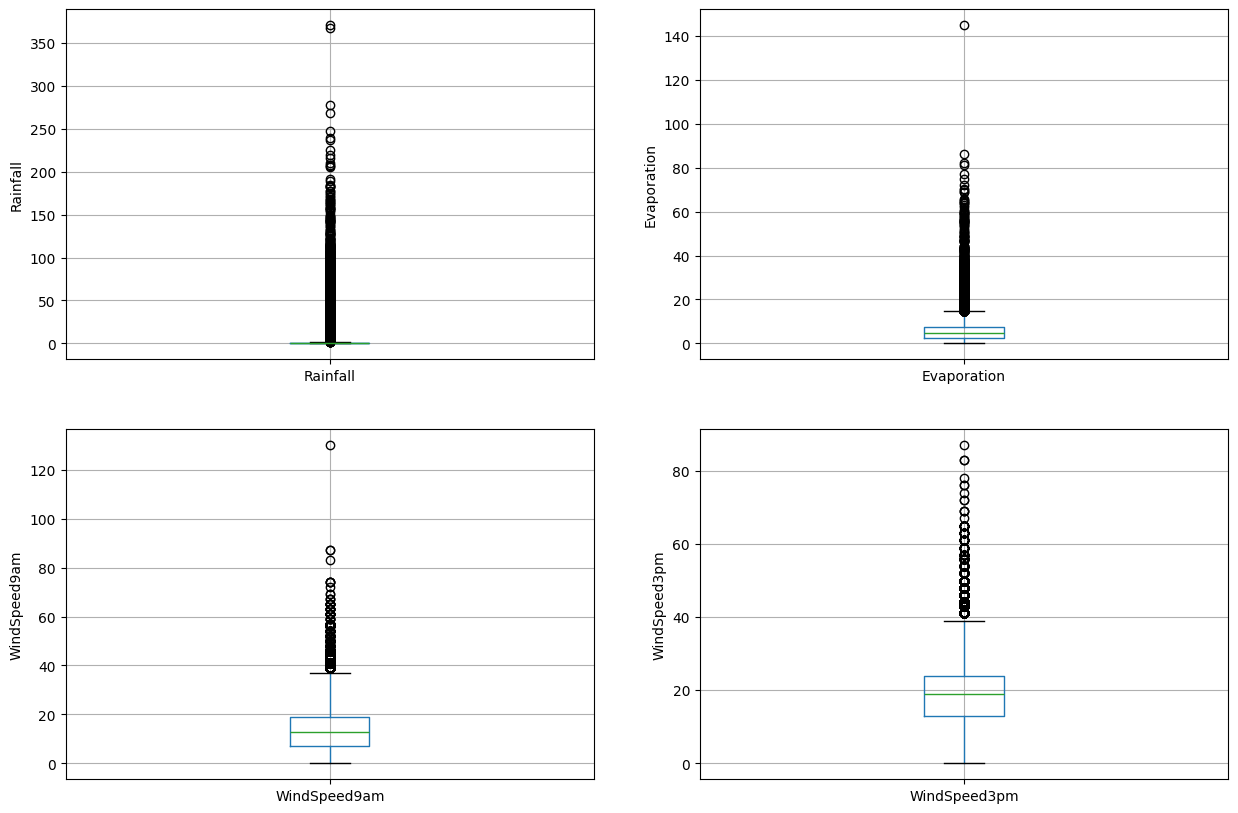

In [ ]:
#Boxplot

plt.figure(figsize = (15, 10))

plt.subplot(2,2,1)
fig = df.boxplot(column = 'Rainfall')
fig.set_title('')
fig.set_ylabel('Rainfall')

plt.subplot(2,2,2)
fig = df.boxplot(column = 'Evaporation')
fig.set_title('')
fig.set_ylabel('Evaporation')

plt.subplot(2,2,3)
fig = df.boxplot(column = 'WindSpeed9am')
fig.set_title('')
fig.set_ylabel('WindSpeed9am')

plt.subplot(2,2,4)
fig = df.boxplot(column = 'WindSpeed3pm')
fig.set_title('')
fig.set_ylabel('WindSpeed3pm')

Observamos que existen varios elementos atipicos en diferentes variables numericas, vamos a profundizar el analisis trazando una histogramas para verificar la distribucion y determinar si son normales o sesgadas. Entonces analizaremos los valores extremos dentro de la funcion del rango intercuartilico que es una tecnica para eliminar valores de ese tipo univariante

Text(0, 0.5, 'RainTomorrow')

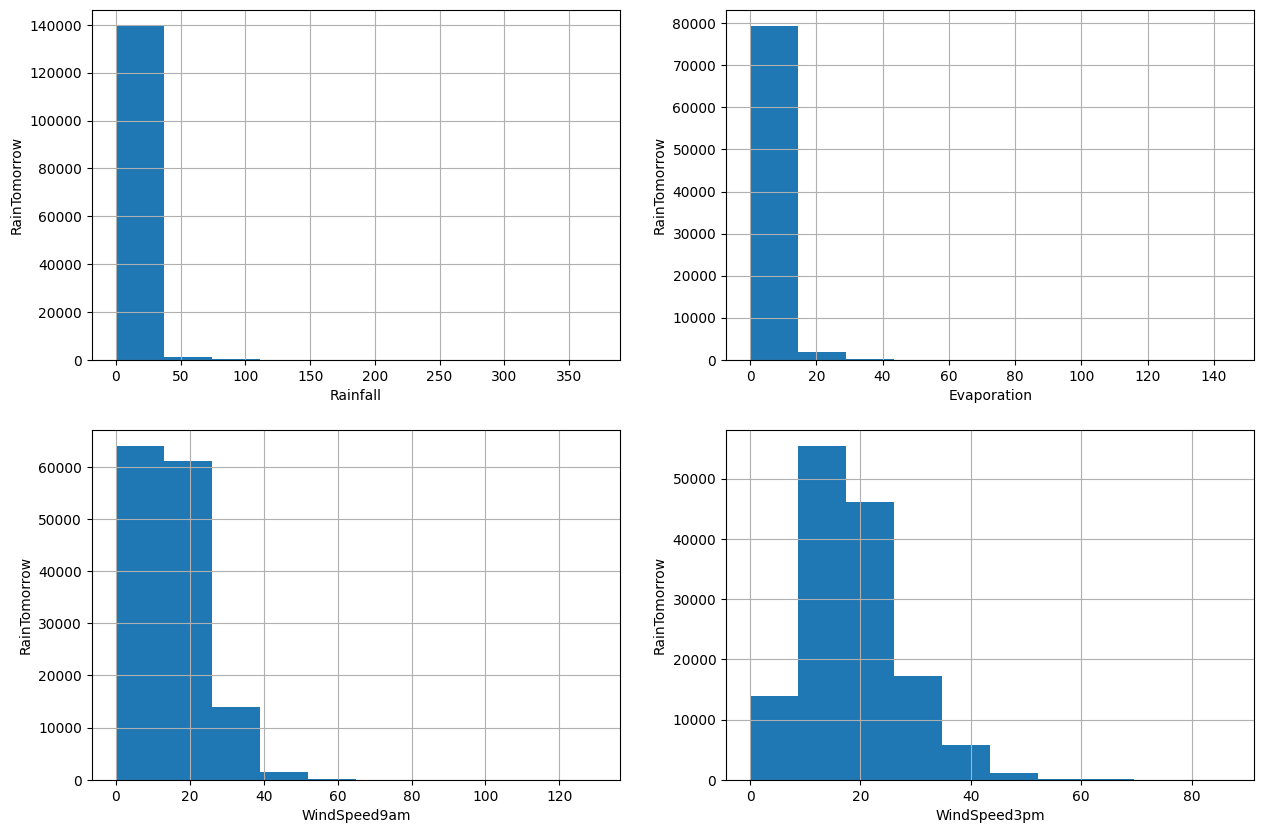

In [ ]:
#Histograma

plt.figure(figsize = (15, 10))

plt.subplot(2,2,1)
fig = df.Rainfall.hist(bins=10)
fig.set_xlabel('Rainfall')
fig.set_ylabel('RainTomorrow')

plt.subplot(2,2,2)
fig = df.Evaporation.hist(bins=10)
fig.set_xlabel('Evaporation')
fig.set_ylabel('RainTomorrow')

plt.subplot(2,2,3)
fig = df.WindSpeed9am.hist(bins=10)
fig.set_xlabel('WindSpeed9am')
fig.set_ylabel('RainTomorrow')

plt.subplot(2,2,4)
fig = df.WindSpeed3pm.hist(bins=10)
fig.set_xlabel('WindSpeed3pm')
fig.set_ylabel('RainTomorrow')


In [ ]:
# Vamos a buscar los valores atipicos para cada variable

IQR = df.Rainfall.quantile(0.75)-df.Rainfall.quantile(0.25)
limite_inferior_rainfall = df.Rainfall.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = df.Rainfall.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Rainfall <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Rainfall <-2.4000000000000004 o > 3.2


In [ ]:
# Vamos a buscar los valores atipicos para cada variable

IQR = df.Evaporation.quantile(0.75)-df.Evaporation.quantile(0.25)
limite_inferior = df.Evaporation.quantile(0.25) - (IQR * 3)
limite_superior = df.Evaporation.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Evaporation <{bajo} o > {alto}'.format(bajo = limite_inferior, alto = limite_superior))

Los valores atipicos de Evaporation <-11.800000000000002 o > 21.800000000000004


In [ ]:
# Vamos a buscar los valores atipicos para cada variable

IQR = df.WindSpeed9am.quantile(0.75)-df.WindSpeed9am.quantile(0.25)
limite_inferior = df.WindSpeed9am.quantile(0.25) - (IQR * 3)
limite_superior = df.WindSpeed9am.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de WindSpeed9am <{bajo} o > {alto}'.format(bajo = limite_inferior, alto = limite_superior))

Los valores atipicos de WindSpeed9am <-29.0 o > 55.0


In [ ]:
# Vamos a buscar los valores atipicos para cada variable

IQR = df.WindSpeed3pm.quantile(0.75)-df.WindSpeed3pm.quantile(0.25)
limite_inferior = df.WindSpeed3pm.quantile(0.25) - (IQR * 3)
limite_superior = df.WindSpeed3pm.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de WindSpeed3pm <{bajo} o > {alto}'.format(bajo = limite_inferior, alto = limite_superior))

Los valores atipicos de WindSpeed3pm <-20.0 o > 57.0


## Creación de Pipelines para tranformaciones automatizadas

In [ ]:
# Definir las columnas categóricas y numéricas
columnas_categoricas =  [var for var in df.columns if df[var].dtype == 'O' and var != 'RainTomorrow' and var !='RainToday']
columna_binaria = ['RainToday']
columnas_numericas = [ var for var in df.columns if df[var].dtype != 'O']

In [ ]:
# Pipeline para columnas categóricas con OneHotEncoding

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

transformador_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [ ]:
# Pipeline para la columna 'RainToday' con BinaryEncoding
transformador_binario = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('binario', BinaryEncoder())
])

In [ ]:
# Pipeline para columnas numéricas con imputación, manejo de outliers y escalado
transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('robust_scaler', RobustScaler()),
    ('escalador', MinMaxScaler())
])

#### Robust Scaler

Xescalada = X - Mediana / IQR

#### Min-Max Scaler
Xescalada = X - Xmin / Xmax - Xmin

In [ ]:
preprocesador_completo = ColumnTransformer(
    transformers=[
        ('numerico', transformador_numerico, columnas_numericas),
        ('categorico', transformador_categorico, columnas_categoricas),
        ('binario', transformador_binario, columna_binaria)
    ]
)

In [ ]:
# Pipeline completo con preprocesamiento y modelo de regresión logística
pipeline_logistic_regression = Pipeline(steps=[
    ('preprocesador', preprocesador_completo),
    ('clasificador', LogisticRegression(solver='liblinear', random_state=0))
])

## Declaracion del Matriz X y la Variable Objetivo Y

In [ ]:
X = df.drop(['RainTomorrow'], axis = 1)

y = df['RainTomorrow']

## Dividir los Datos

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
X_train.shape, X_test.shape

((113754, 24), (28439, 24))

## Entrenamiento del Modelo

In [ ]:
pipeline_logistic_regression.fit(X_train, y_train)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('numerico',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('robust_scaler',
                                                                   RobustScaler()),
                                                                  ('escalador',
                                                                   MinMaxScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', '...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am',
                                                   'WindDir3pm']),
                                                 ('binario',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('binario',
                                                                   BinaryEncoder())]),
                                                  ['RainToday'])])),
                ('clasificador',
                 LogisticRegression(random_state=0, solver='liblinear'))])

## Predecir los resultados

In [ ]:
y_pred_test = pipeline_logistic_regression.predict(X_test)

y_pred_test

array(['No', 'No', 'No', ..., 'No', 'No', 'Yes'], dtype=object)

In [ ]:
# Metodo de Obtener la Probabilidad de la prediccion

#Recuerden que el metodo proporciona la posibilidad de que la variabble predictora (y) se clasifique entre 1 y 0

#La probabilidad de que no llueva manana

pipeline_logistic_regression.predict_proba(X_test)[:,0]

array([0.91217734, 0.85241478, 0.8279667 , ..., 0.97667532, 0.79137664,
       0.33527177])

In [ ]:
#La probabilidad de que  llueva manana

pipeline_logistic_regression.predict_proba(X_test)[:,1]

array([0.08782266, 0.14758522, 0.1720333 , ..., 0.02332468, 0.20862336,
       0.66472823])

## Precision del Modelo




### **6.1. Accuracy (Exactitud)**

**Exactitud (Accuracy)** mide el porcentaje de predicciones correctas sobre el total de predicciones realizadas:

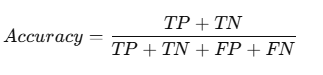

Donde:
- **TP**: Verdaderos Positivos.
- **TN**: Verdaderos Negativos.
- **FP**: Falsos Positivos.
- **FN**: Falsos Negativos.



In [ ]:
accuracy = accuracy_score(y_test, y_pred_test)
print(f"Precisión (Accuracy): {accuracy:.2f}")

Precisión (Accuracy): 0.85


Para determinar si el modelo esta sobre-entrenado se debe de comparar los resultados de la precision del modelo entrenado con el modelo de prueba, si los resultados son distantes el modelo esta sobre-ajustado y las predicciones no son correctas porque no sabe que hacer ante nuevos escenarios.

In [ ]:
y_pred_train = pipeline_logistic_regression.predict(X_train)

y_pred_train

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [ ]:
accuracy = accuracy_score(y_train, y_pred_train)
print(f"Precisión (Accuracy): {accuracy:.2f}")

Precisión (Accuracy): 0.85


La precision del modelo entrenado es de 0.85% y la precision del modelo de prueba es de 0.85%. Eso quiere decir que los valores son comparables, por lo tanto no hay sobreajuste del modelo entrenado.

In [ ]:
# Revisar la distribucion de Test

y_test.value_counts()

,count
RainTomorrow,
No,22067
Yes,6372


In [ ]:
puntuacion_nula = (22067/(22067 + 6372))

print('La precision nula del modelo es : {0:0.4f}'.format(puntuacion_nula))

La precision nula del modelo es : 0.7759


## **Matriz de Confusión**

Es una herramienta para resumir el rendimeinto de un algoritmo de clasificacion. Ya que nos da una imagen clara del rendimiento del modelo de clasificacion y los tipos de errores producidos por ese modelo. Entonces nos da un resumen de las predicciones correctas e incorrectas desglosadas por cada categoria.

Hay 4 tipos de resultados posibles.

  1. **Verdaderos Positivos (TP):** Los verdaderos positivos ocurre cuando predecimos que una observacion (fila), pertenece a una determinada clase y la observacion en realidad si pertenece a esa clase.
  2.**Verdaderos Negativos (TN):** Los verdaderos negativos ocurre cuando predecimos que una observacion (fila), **NO** pertenecce a una clase determinada y la observacion en realidad **No pertenece** a esa clase.
  3.**Falsos Positivos (FP):** Los falsos positivos ocurre cuando predecimos una observacion (fila), pertenece a una determinada clase y la observacoin en realidad **NO** perteneceia a esa clase. El error tipo 1.
  4. **Falsos Negativos (FN):** Los falsos negaivos ocurre cuando predecimos que una observacion (fila), **NO** pertenece a una determinada clase y la observacion en realidad si pertenecia a esa clase. El error tipo 2. El error mas grave.

  Ejemplo: Voy a predecir si mañana no llueve
  * Fila 1: Mi prediccion indicó que mañana no llovia y efectivamente no llovió (TP)
  * Fila 2: Mi prediccion indicó que mañana si llueve y efectivamete si llovió (TN). (lo contrario a la hipotesis pero que si paso)
  * Fila 3. Mi prediccion indicó que mañana no llueve pero si llovió (FP)
  * Fila 4. Mi predicción indicó que mañana llovía y no llovío (FN)

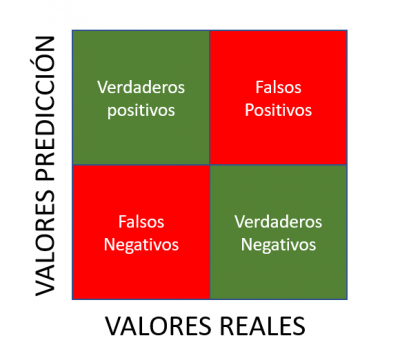

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Matriz de Confusion\n\n', cm)

print('\nVerdaderos Positivos (TP): ', cm[0,0])

print('\nVerdaderos Negaticos (TN): ', cm[1,1])

print('\nFalsos Positivos (FP): ', cm[0,1])

print('\nFalsos Negaticos (FN): ', cm[1,0])

Matriz de Confusion

 [[20902  1165]
 [ 3102  3270]]

Verdaderos Positivos (TP):  20902

Verdaderos Negaticos (TN):  3270

Falsos Positivos (FP):  1165

Falsos Negaticos (FN):  3102


La matriz de confusion muestra: 20902 + 3270 = 24172 es la cantidad de predicciones correcta y 1165 + 3102 = 4267 es la cantidad de predicciones incorrectas.

* **Verdaderos Positivos:** (El Valor Actual es 1 y la prediccion fue 1) = 20902
* **Verdaderos Negativos:** (El Valor Actual fue 0 y la prediccion fue 0) = 3270
* **Falsos Positivos:** (El Valor Actual es 0 y se predijo que era 1)= 1165 El error tipo 1
* **Falsos Negativos:** (El Valor Actual era 1 y se predijo 0) = 3102 El error es tipo 2

Text(0.5, 1.0, 'Matriz de Confunsion')

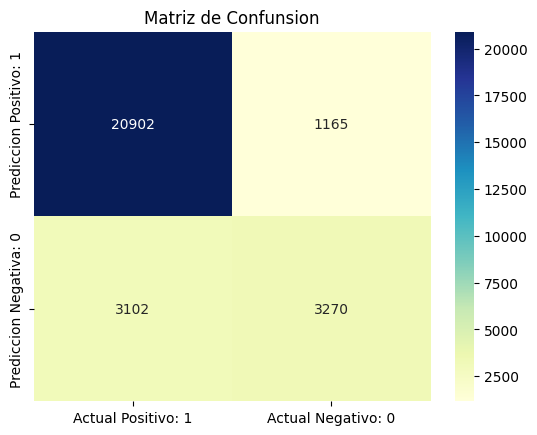

In [ ]:
# Realizar la matriz de confusion en un mapa de calor

cm_matriz = pd.DataFrame(data = cm, columns = ['Actual Positivo: 1', 'Actual Negativo: 0'],
                         index = ['Prediccion Positivo: 1', 'Prediccion Negativa: 0'])

sns.heatmap(cm_matriz, annot = True, fmt = 'd', cmap = 'YlGnBu')
plt.title('Matriz de Confunsion')

## Exactitud de la Clasificacion

In [ ]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [ ]:
precision_clasificacion = (TP + TN ) / float(TP+ TN + FP+ FN)

print('Precision de la clasificacion es: {0:0.4f}'.format(precision_clasificacion))

Precision de la clasificacion es: 0.8500


# Metricas de Clasificacion

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, log_loss, cohen_kappa_score, confusion_matrix, classification_report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

          No       0.87      0.95      0.91     22067
         Yes       0.74      0.51      0.61      6372

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439






### **Precision (Precisión)**


**Precisión (Precision)** mide la proporción de verdaderos positivos sobre todas las predicciones positivas:

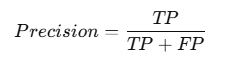


In [ ]:
precision = precision_score(y_test, y_pred_test, pos_label='Yes')
print(f"Precisión (Precision): {precision:.2f}")

Precisión (Precision): 0.74





### **Recall (Exhaustividad)**

**Recall** mide la capacidad del modelo para identificar todos los positivos verdaderos:

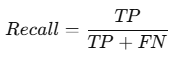

In [ ]:
recall = recall_score(y_test, y_pred_test, pos_label='Yes')
print(f"Recall: {recall:.2f}")

Recall: 0.51



### **F1-Score**


El **F1-Score** es la media armónica entre la precisión y el recall. Es útil cuando necesitas un balance entre ambos:

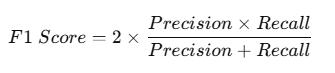


In [ ]:
f1 = f1_score(y_test, y_pred_test, pos_label='Yes')
print(f"F1-Score: {f1:.2f}")

F1-Score: 0.61


# Ajuste del Umbral de las Predicciones

In [ ]:
y_pred_prob = pipeline_logistic_regression.predict_proba(X_test)[0:10]

y_pred_prob

array([[0.91217734, 0.08782266],
       [0.85241478, 0.14758522],
       [0.8279667 , 0.1720333 ],
       [0.99031082, 0.00968918],
       [0.95950219, 0.04049781],
       [0.97980808, 0.02019192],
       [0.17725258, 0.82274742],
       [0.22862922, 0.77137078],
       [0.90594695, 0.09405305],
       [0.85112685, 0.14887315]])

**Observaciones:**

1. En cada fila los numeros son 1
2. Hay 2 columnas que corresponder a 2 clases 0 y 1
  * Clase 0 = Es la probabilidad pronosticada que no llueva manana
  * Clase 1 = Es la probabilidad pronosticada de que llueve manana
3. Importancia de las probabilidad predichas
  * Podemos clasificar las observaciones por probabilidades de si llueve o no manana.
  * Predecir Probabilidades
  * Elegir la clase con la mayor probabilidad
4. Nivel del umbral de clasificacion
  * Hay un nivel de umbral de clasificacion 0.5
  * Clase 1 = La probabilidad de que llueve maanana se predice si la probabilidad es > 0.5
  * Clase 0: Es la probabilidad de que no llueva se predice su la probabilidad es < 0.5

In [ ]:
y_pred_prob_df = pd.DataFrame(data = y_pred_prob, columns = ['Prob de que no Llueva Mañana (0)', 'Prob de que si llueva mañana(1)'])
y_pred_prob_df

,Prob de que no Llueva Mañana (0),Prob de que si llueva mañana(1)
0,0.912177,0.087823
1,0.852415,0.147585
2,0.827967,0.172033
3,0.990311,0.009689
4,0.959502,0.040498
5,0.979808,0.020192
6,0.177253,0.822747
7,0.228629,0.771371
8,0.905947,0.094053
9,0.851127,0.148873


In [ ]:
# Extraer las primeras 10 predicciones de que va llover manana

pipeline_logistic_regression.predict_proba(X_test)[0:10,1]

array([0.08782266, 0.14758522, 0.1720333 , 0.00968918, 0.04049781,
       0.02019192, 0.82274742, 0.77137078, 0.09405305, 0.14887315])

In [ ]:
#Guaradr las probabilidad de que si lluevan en una matriz

y_pred1 = pipeline_logistic_regression.predict_proba(X_test)[:,1]

Text(0, 0.5, 'Frecuencia')

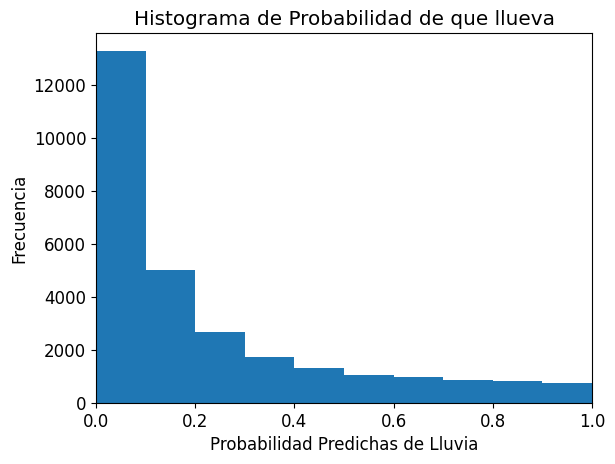

In [ ]:
#Plotear el Histograma de las probabilidades de las predicciones

plt.rcParams['font.size'] = 12

plt.hist(y_pred1, bins = 10)

plt.title('Histograma de Probabilidad de que llueva')

plt.xlim(0,1)

plt.xlabel('Probabilidad Predichas de Lluvia')
plt.ylabel('Frecuencia')

**Conclusiones**

1. El histograma esta altamente sesgado
2. La primera columna nos dice que hay aproximadamente 15000 observaciones con probabilidades estre 0.0 y 0.1.
3. Hay un numero pequenio de observaciones con probabilidad >0.5
4. Ese numero corresponde a las observaciones que predicen que manana si habra lluvia.
5. Osea que la gran mayoria de observaciones dicen que no va a llover

### **AUC-ROC**

Otra herramienta para medir visualmente el rendimiento del modelo de clasificacion es la curva **curva ROC**. ROC significa Curva Caracterisitca de funcionamiento del receptor. Una curva ROC es una grafica que muestra el rendimiento de un modelo de clasificacion en varios niveles de umbral de clasificacion.

La curva ROC traza la **tasa de verdaderos positivos (TTP)** contra la **tasa de falsos positivos (TFP)** en varios niveles del umbral.

La tasa positiva verdadera tambien se llama recall. Se define como la relacion de TP a (TP + FN).

La tasa de falsos positivos se define como la relacion entre FP y (FP + TN)

En la Curva ROC, nos centraremos en la TPR (True Positve Rate) y el FPR (False Positive Rate) de un solo punto. Esto nos dara el rendimiento general de la curva ROC, que consiste en el Examen de las Politicas Comerciales y el Examen de las Politicas Comerciales en varios niveles del umbral. Por lo tanto, una curva ROC traza TPR vrs FPR en diferentes niveles del umbral de clasificacion. Si bajamos los niveles del umbral, puede resultar en que mas elementos se clasifiquen como positivos, por lo cual aumentara tantos los Verdaderos Positivos (TP) como los Falsos Positivos (FP).

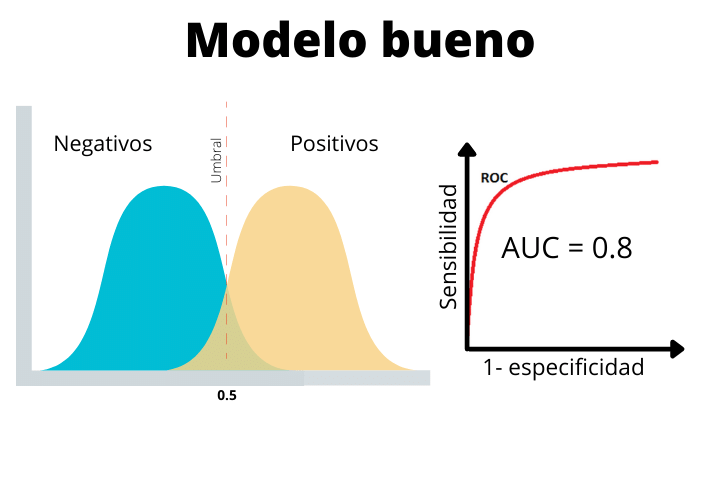


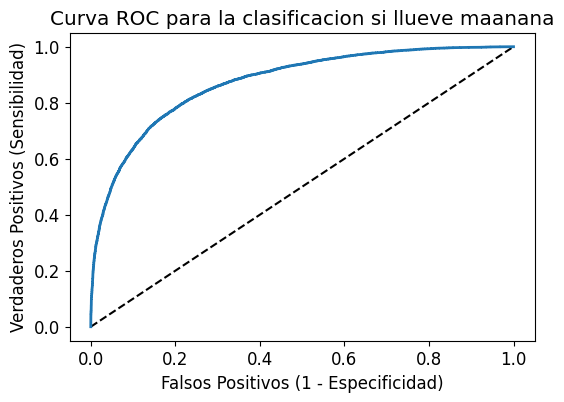

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, umbral = roc_curve(y_test,y_pred1, pos_label='Yes')
plt.figure(figsize = (6,4))
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr, tpr, linewidth = 2)
plt.title('Curva ROC para la clasificacion si llueve maanana')
plt.rcParams['font.size'] = 12
plt.xlabel('Falsos Positivos (1 - Especificidad)')
plt.ylabel('Verdaderos Positivos (Sensibilidad)')
plt.show()

Conclusiones:

EL ROC AUC es un resumen de un solo numero del rendimiento del clasificador. Cuanto mayor sea el valor, mejor sera el clasificador

In [ ]:
from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, y_pred1)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

ROC AUC : 0.8726


In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_roc_auc = cross_val_score(pipeline_logistic_regression, X_train, y_train, cv = 5, scoring = 'roc_auc').mean()

print('Validacion Cruzada del ROC AUC: {:.4F}'.format(cross_val_roc_auc))

Validacion Cruzada del ROC AUC: 0.8692



### **Log Loss**


**Log Loss** penaliza las predicciones incorrectas de probabilidad:

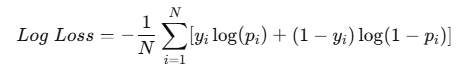

In [ ]:
log_loss_value = log_loss(y_test, y_pred1)
print(f"Log Loss: {log_loss_value:.2f}")

Log Loss: 0.35



### **Cohen's Kappa**


El **Cohen’s Kappa** mide el grado de acuerdo entre las predicciones y las etiquetas reales, corrigiendo por el acuerdo que podría ocurrir por azar:

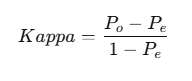

In [ ]:
kappa = cohen_kappa_score(y_test, y_pred_test)
print(f"Cohen's Kappa: {kappa:.2f}")

Cohen's Kappa: 0.52


## HiperParametros Optimizacion usando GridSearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV

parametros = {
    'clasificador__penalty': ['l1', 'l2'],
    'clasificador__C': [1, 10],
    'clasificador__solver': ['liblinear']
}

grid_search = GridSearchCV(estimator=pipeline_logistic_regression,
                           param_grid=parametros,
                           scoring='accuracy',
                           cv=5,
                           verbose=0)

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(transformers=[('numerico',
                                                                         Pipeline(steps=[('imputador',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('robust_scaler',
                                                                                          RobustScaler()),
                                                                                         ('escalador',
                                                                                          MinMaxScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          '...
                                                                          'WindDir9am',
                                                                          'WindDir3pm']),
                                                                        ('binario',
                                                                         Pipeline(steps=[('imputador',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('binario',
                                                                                          BinaryEncoder())]),
                                                                         ['RainToday'])])),
                                       ('clasificador',
                                        LogisticRegression(random_state=0,
                                                           solver='liblinear'))]),
             param_grid={'clasificador__C': [1, 10],
                         'clasificador__penalty': ['l1', 'l2'],
                         'clasificador__solver': ['liblinear']},
             scoring='accuracy')

In [ ]:
print('GridSearch CV las mejores puntuaciones: {:.4f}\n\n'.format(grid_search.best_score_))

print('Los mejores resultados de los parametros: ','\n\n', grid_search.best_params_)

print('\n\nGridSearch CV mejor puntuacion del test es: {0:0.4f}'.format(grid_search.score(X_test,y_test)))

GridSearch CV las mejores puntuaciones: 0.8475


Los mejores resultados de los parametros:  

 {'clasificador__C': 10, 'clasificador__penalty': 'l2', 'clasificador__solver': 'liblinear'}


GridSearch CV mejor puntuacion del test es: 0.8501


1. La puntuacion del modelo logistico es de 0.8501 Por lo tanto el modelo hace un muy buen trabajo al predecir si va a llover mañana o no.

2. El modelo no mostraba signos sobreajuste.

3. El aumento del nivel del umbral dio como resultado una mayor precision.

In [ ]:
best_model = grid_search.best_estimator_

### **Calibración del Modelo**
Calibramos el modelo utilizando CalibratedClassifierCV para mejorar las predicciones de probabilidad.

In [ ]:
calibrated_model = CalibratedClassifierCV(estimator=best_model, cv=5)
calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocesador',
                                                  ColumnTransformer(transformers=[('numerico',
                                                                                   Pipeline(steps=[('imputador',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('robust_scaler',
                                                                                                    RobustScaler()),
                                                                                                   ('escalador',
                                                                                                    MinMaxScaler())]),
                                                                                   ['MinTemp',
                                                                                    'MaxTemp',
                                                                                    'Rainfall',
                                                                                    'Evaporation',
                                                                                    'Sunshine',
                                                                                    'WindGustSpeed',
                                                                                    'WindSpeed9am',
                                                                                    'WindSpeed3pm',
                                                                                    'Humi...
                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                   ('onehot',
                                                                                                    OneHotEncoder(drop='first',
                                                                                                                  handle_unknown='ignore'))]),
                                                                                   ['Location',
                                                                                    'WindGustDir',
                                                                                    'WindDir9am',
                                                                                    'WindDir3pm']),
                                                                                  ('binario',
                                                                                   Pipeline(steps=[('imputador',
                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                   ('binario',
                                                                                                    BinaryEncoder())]),
                                                                                   ['RainToday'])])),
                                                 ('clasificador',
                                                  LogisticRegression(C=10,
                                                                     random_state=0,
                                                                     solver='liblinear'))]))

### **Predicciones y Evaluación del Modelo**
Utilizamos varias métricas para evaluar el rendimiento del modelo.

In [ ]:
# Predicción y Evaluación
y_pred = calibrated_model.predict(X_test)
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Mejores Hiperparámetros:", grid_search.best_params_)
print(f"Precisión (Accuracy): {accuracy:.2f}")

Mejores Hiperparámetros: {'clasificador__C': 10, 'clasificador__penalty': 'l2', 'clasificador__solver': 'liblinear'}
Precisión (Accuracy): 0.85


### **Guardar el modelo entrenado**

In [ ]:
joblib.dump(calibrated_model, 'modelo_clasificacion.pkl')

['modelo_clasificacion.pkl']

### **Cargar el modelo para hacer predicciones con nuevos datos**
Una vez que el modelo esté guardado, se puede cargar y utilizar para predecir nuevos datos.

In [ ]:
modelo = joblib.load('modelo_clasificacion.pkl')

### **Cargar el nuevo dataset**

In [ ]:
df_nuevos = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/datos_nuevos_lluvia.csv')
df_nuevos.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,2024-10-01,Albury,14.624093,21.540168,5.080559,2.028918,1.233533,E,40.147727,SE,S,15.674888,25.907200,53.889059,47.331818,1019.023752,1001.750917,0.023950,1.083594,12.827480,33.685964,No
1,2024-10-02,Albury,15.954025,34.734171,3.580733,4.525956,8.641407,S,45.683494,S,S,8.131674,28.782715,70.457739,38.851105,1015.255937,1007.827239,7.658212,7.621861,18.647945,27.507274,Yes
2,2024-10-03,Albury,11.350693,28.416836,6.152235,4.611939,3.729639,SE,24.510020,SE,NW,20.766819,28.641884,60.232770,35.731173,1018.991768,1006.915303,3.225632,0.134486,12.102721,30.138841,Yes
3,2024-10-04,Albury,12.016470,22.260646,1.260838,1.630809,9.321897,SE,37.992715,S,NW,14.074552,24.060130,51.352768,49.882797,1002.577881,1005.806139,1.960887,2.774639,14.559501,34.517685,Yes
4,2024-10-05,Albury,12.761601,26.666513,1.421930,3.021455,5.696454,SW,21.883326,N,E,8.766957,15.118606,65.270088,23.741874,1009.590836,1004.163907,1.954262,4.326052,14.130804,32.563483,No


### **Predecir con los nuevos datos**

In [ ]:
df_nuevos['Date'] = pd.to_datetime(df_nuevos['Date'])
df_nuevos['Año'] = df_nuevos['Date'].dt.year
df_nuevos['Mes'] = df_nuevos['Date'].dt.month
df_nuevos['Día'] = df_nuevos['Date'].dt.day

# Eliminar la columna 'Date' ya que no es necesaria para el modelo
df_nuevos.drop('Date', axis=1, inplace=True)

In [ ]:
# Predecir si lloverá mañana para los nuevos datos
predicciones = modelo.predict(df_nuevos)

# Añadir las predicciones al DataFrame
df_nuevos['RainTomorrow_Pred'] = predicciones

# Mostrar el dataset final con las predicciones incluidas
df_nuevos

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Año,Mes,Día,RainTomorrow_Pred
0,Albury,14.624093,21.540168,5.080559,2.028918,1.233533,E,40.147727,SE,S,15.674888,25.907200,53.889059,47.331818,1019.023752,1001.750917,0.023950,1.083594,12.827480,33.685964,No,2024,10,1,Yes
1,Albury,15.954025,34.734171,3.580733,4.525956,8.641407,S,45.683494,S,S,8.131674,28.782715,70.457739,38.851105,1015.255937,1007.827239,7.658212,7.621861,18.647945,27.507274,Yes,2024,10,2,No
2,Albury,11.350693,28.416836,6.152235,4.611939,3.729639,SE,24.510020,SE,NW,20.766819,28.641884,60.232770,35.731173,1018.991768,1006.915303,3.225632,0.134486,12.102721,30.138841,Yes,2024,10,3,No
3,Albury,12.016470,22.260646,1.260838,1.630809,9.321897,SE,37.992715,S,NW,14.074552,24.060130,51.352768,49.882797,1002.577881,1005.806139,1.960887,2.774639,14.559501,34.517685,Yes,2024,10,4,No
4,Albury,12.761601,26.666513,1.421930,3.021455,5.696454,SW,21.883326,N,E,8.766957,15.118606,65.270088,23.741874,1009.590836,1004.163907,1.954262,4.326052,14.130804,32.563483,No,2024,10,5,No
5,Albury,13.660557,26.046118,0.691407,2.311692,5.068072,N,28.465286,N,NW,13.659055,20.342134,61.266841,59.423330,1017.909237,1006.904378,4.471431,1.679476,17.785010,31.278502,Yes,2024,10,6,Yes
6,Albury,19.545270,20.151077,4.960353,3.628334,9.941765,SE,20.309711,S,SE,23.180042,21.925892,44.598874,40.831624,1005.017214,1001.634795,3.595131,1.468978,14.536260,31.313868,Yes,2024,10,7,No
7,Albury,7.850671,28.448238,2.448522,1.127777,3.895516,NE,43.796117,N,W,22.772387,19.899839,50.640922,68.868667,1018.286206,1004.130180,2.203554,6.195858,11.094313,30.052665,No,2024,10,8,Yes
8,Albury,8.605607,23.675068,0.581343,2.170657,6.467910,N,32.635242,SE,W,9.022335,27.594744,75.323927,76.016528,1004.216595,1001.552525,5.469132,4.362995,20.340257,20.249342,No,2024,10,9,Yes
9,Albury,11.466408,20.354617,7.090299,1.501257,6.393404,SE,22.419858,NE,E,18.098656,23.133432,60.561466,60.745453,1019.074285,1004.750465,1.874085,6.437617,23.445895,29.836653,Yes,2024,10,10,Yes


In [ ]:
#Predecir las Probabilidades de Llover o no mañana para los datos nuevos

probabilidades = modelo.predict_proba(df_nuevos)

# Agregar las probabilidades al DataFrame
df_nuevos['Prob_No_Lluvia'] = probabilidades[:, 0]
df_nuevos['Prob_Lluvia'] = probabilidades[:, 1]

# Mostrar el dataset final con las probabilidades incluidas
df_nuevos

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Año,Mes,Día,RainTomorrow_Pred,Prob_No_Lluvia,Prob_Lluvia
0,Albury,14.624093,21.540168,5.080559,2.028918,1.233533,E,40.147727,SE,S,15.674888,25.907200,53.889059,47.331818,1019.023752,1001.750917,0.023950,1.083594,12.827480,33.685964,No,2024,10,1,Yes,0.191996,0.808004
1,Albury,15.954025,34.734171,3.580733,4.525956,8.641407,S,45.683494,S,S,8.131674,28.782715,70.457739,38.851105,1015.255937,1007.827239,7.658212,7.621861,18.647945,27.507274,Yes,2024,10,2,No,0.624932,0.375068
2,Albury,11.350693,28.416836,6.152235,4.611939,3.729639,SE,24.510020,SE,NW,20.766819,28.641884,60.232770,35.731173,1018.991768,1006.915303,3.225632,0.134486,12.102721,30.138841,Yes,2024,10,3,No,0.769723,0.230277
3,Albury,12.016470,22.260646,1.260838,1.630809,9.321897,SE,37.992715,S,NW,14.074552,24.060130,51.352768,49.882797,1002.577881,1005.806139,1.960887,2.774639,14.559501,34.517685,Yes,2024,10,4,No,0.785712,0.214288
4,Albury,12.761601,26.666513,1.421930,3.021455,5.696454,SW,21.883326,N,E,8.766957,15.118606,65.270088,23.741874,1009.590836,1004.163907,1.954262,4.326052,14.130804,32.563483,No,2024,10,5,No,0.918146,0.081854
5,Albury,13.660557,26.046118,0.691407,2.311692,5.068072,N,28.465286,N,NW,13.659055,20.342134,61.266841,59.423330,1017.909237,1006.904378,4.471431,1.679476,17.785010,31.278502,Yes,2024,10,6,Yes,0.254369,0.745631
6,Albury,19.545270,20.151077,4.960353,3.628334,9.941765,SE,20.309711,S,SE,23.180042,21.925892,44.598874,40.831624,1005.017214,1001.634795,3.595131,1.468978,14.536260,31.313868,Yes,2024,10,7,No,0.867265,0.132735
7,Albury,7.850671,28.448238,2.448522,1.127777,3.895516,NE,43.796117,N,W,22.772387,19.899839,50.640922,68.868667,1018.286206,1004.130180,2.203554,6.195858,11.094313,30.052665,No,2024,10,8,Yes,0.097491,0.902509
8,Albury,8.605607,23.675068,0.581343,2.170657,6.467910,N,32.635242,SE,W,9.022335,27.594744,75.323927,76.016528,1004.216595,1001.552525,5.469132,4.362995,20.340257,20.249342,No,2024,10,9,Yes,0.421330,0.578670
9,Albury,11.466408,20.354617,7.090299,1.501257,6.393404,SE,22.419858,NE,E,18.098656,23.133432,60.561466,60.745453,1019.074285,1004.750465,1.874085,6.437617,23.445895,29.836653,Yes,2024,10,10,Yes,0.124599,0.875401
